# Data preparation - Palmer Penguins

Este notebook hace limpieza básica del dataset `palmerpenguins` y genera un CSV limpio.


In [2]:
import pandas as pd
from palmerpenguins import load_penguins
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [3]:
df = load_penguins()
print(df.shape)
df.head()


(344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## EDA — Datos crudos

Exploración antes de aplicar cualquier limpieza.

In [4]:
print("=== Info ===")
df.info()
print("\n=== Describe ===")
df.describe()


=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB

=== Describe ===


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


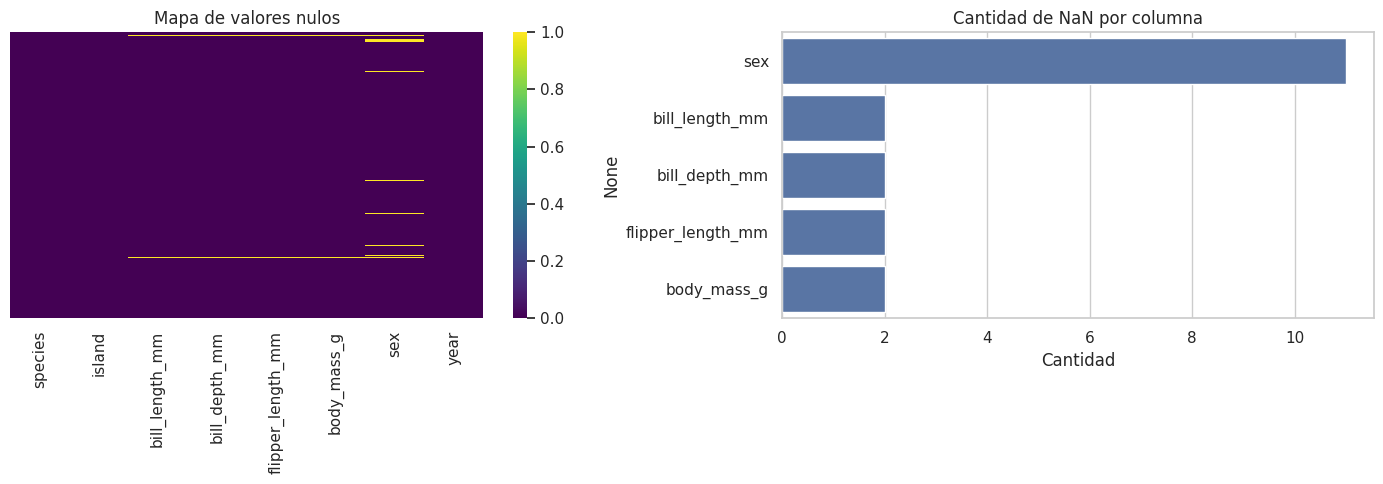

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de nulos
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis", ax=axes[0])
axes[0].set_title("Mapa de valores nulos")

# Conteo de NaN por columna
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
sns.barplot(x=null_counts.values, y=null_counts.index, ax=axes[1])
axes[1].set_title("Cantidad de NaN por columna")
axes[1].set_xlabel("Cantidad")

plt.tight_layout()
plt.show()

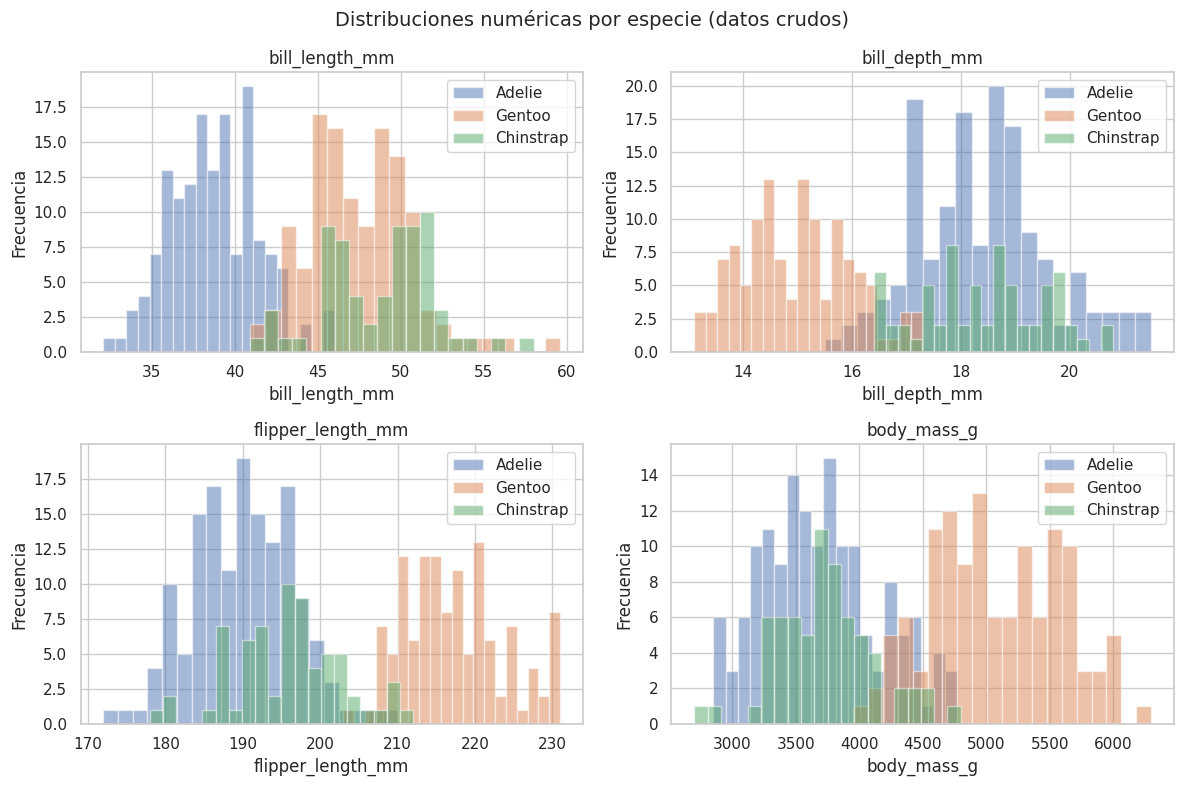

In [6]:
num_vars = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var in zip(axes.flat, num_vars):
    for species in df["species"].dropna().unique():
        subset = df[df["species"] == species]
        ax.hist(subset[var].dropna(), bins=20, alpha=0.5, label=species)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Frecuencia")
    ax.legend()

fig.suptitle("Distribuciones numéricas por especie (datos crudos)", fontsize=14)
plt.tight_layout()
plt.show()

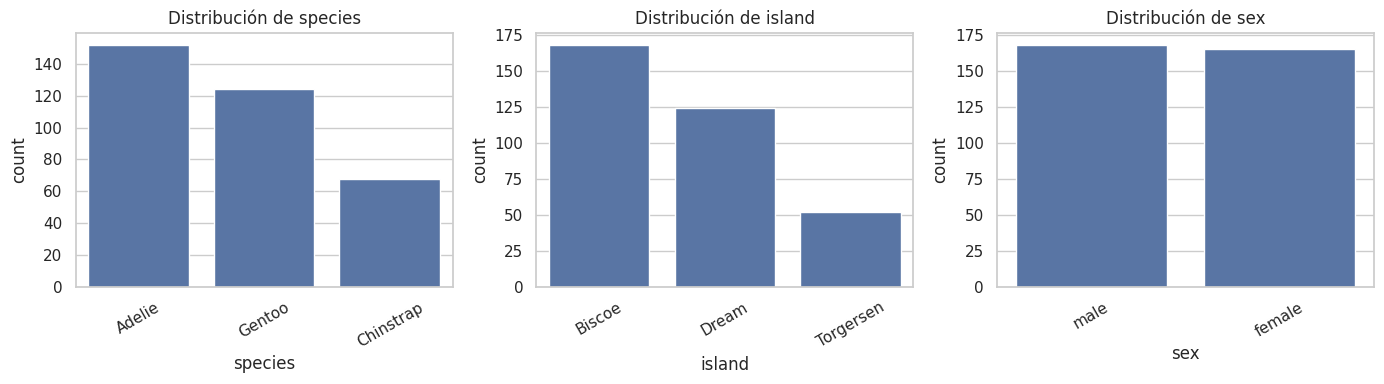

In [7]:
cat_vars = ["species", "island", "sex"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, cat_vars):
    sns.countplot(data=df, x=var, ax=ax, order=df[var].value_counts().index)
    ax.set_title(f"Distribución de {var}")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

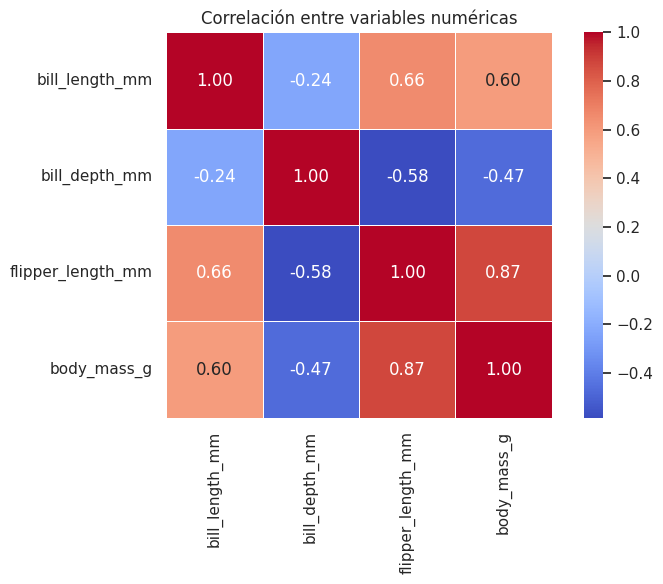

In [8]:
plt.figure(figsize=(8, 6))
corr = df[num_vars].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

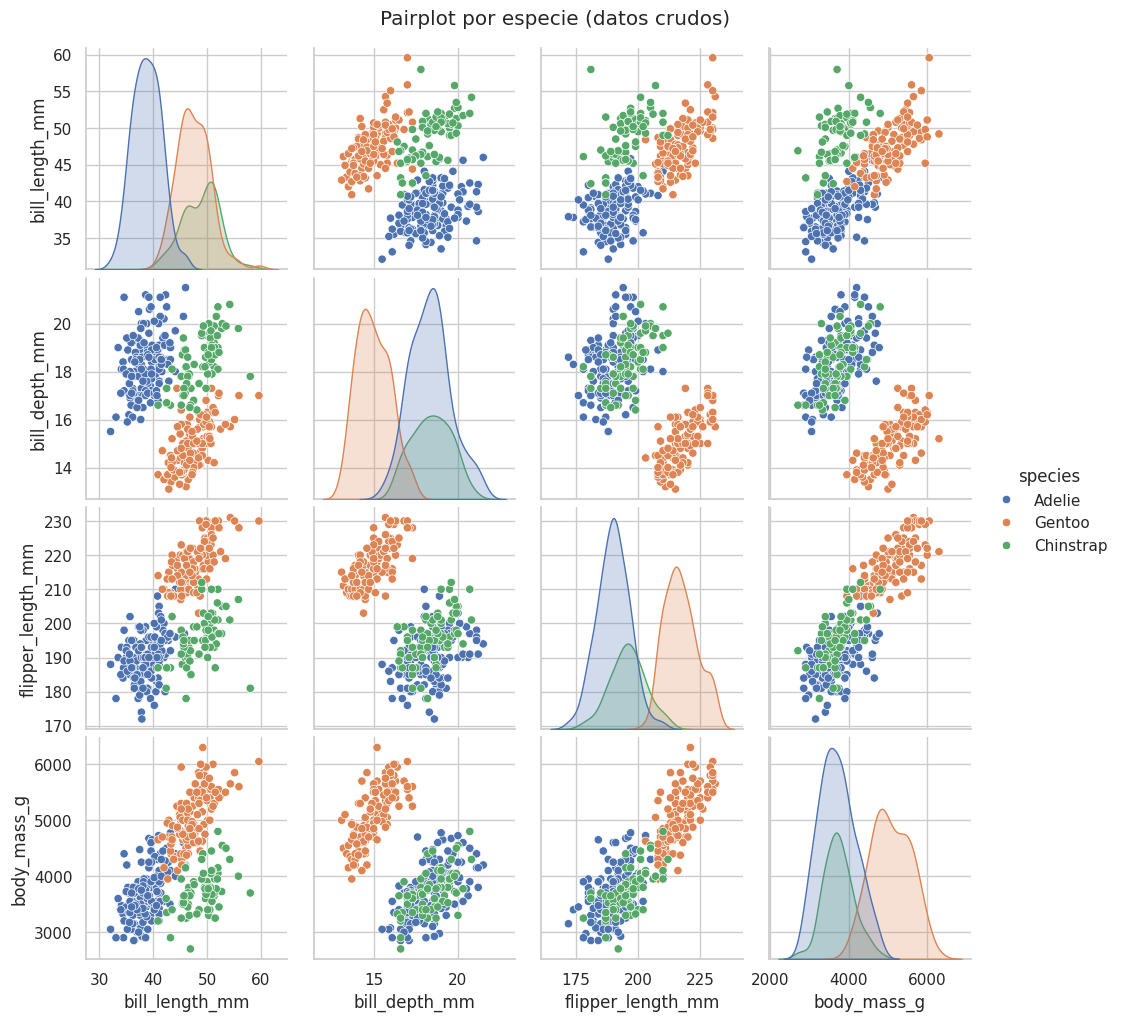

In [9]:
sns.pairplot(df, vars=num_vars, hue="species", diag_kind="kde")
plt.suptitle("Pairplot por especie (datos crudos)", y=1.02)
plt.show()

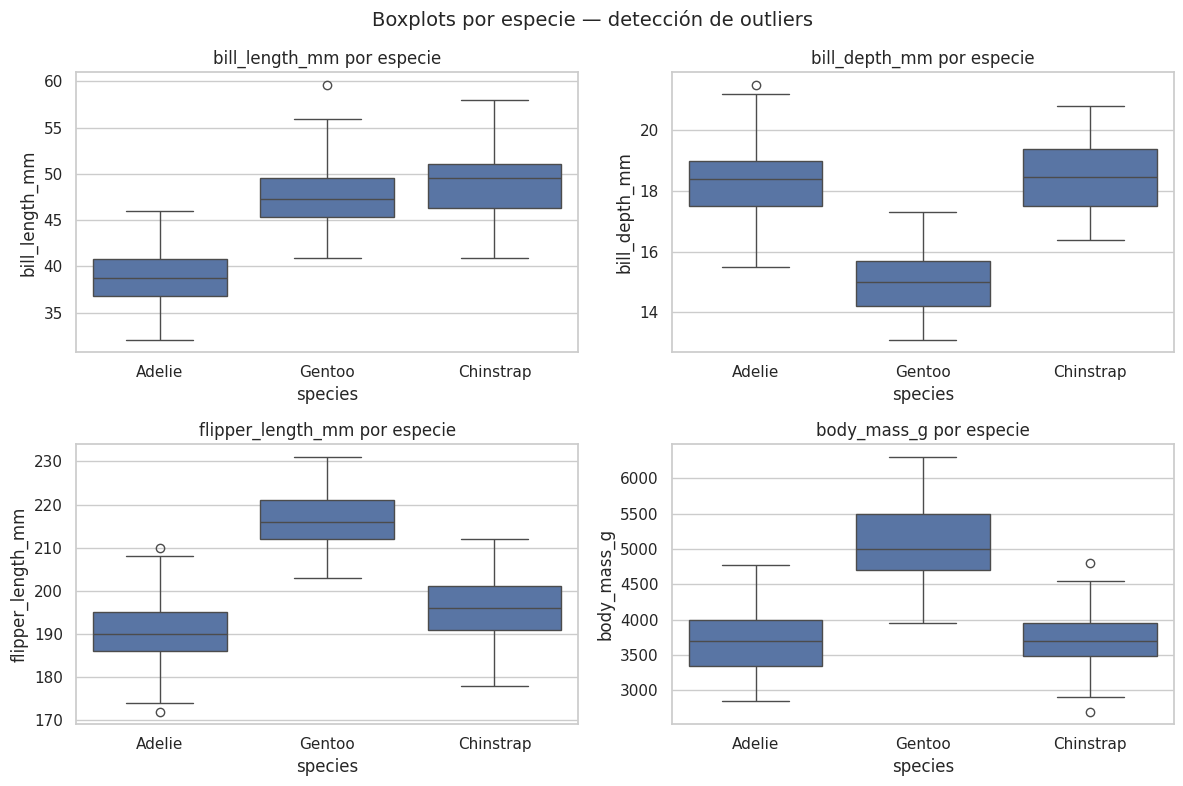

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var in zip(axes.flat, num_vars):
    sns.boxplot(data=df, x="species", y=var, ax=ax)
    ax.set_title(f"{var} por especie")

fig.suptitle("Boxplots por especie — detección de outliers", fontsize=14)
plt.tight_layout()
plt.show()

## Limpieza básica

- Elimina duplicados.
- Normaliza columnas de texto.
- Imputa valores faltantes numéricos con la mediana por especie.
- Imputa `sex` faltante con `unknown`.


In [11]:
df_clean = df.copy()

# Remove duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed: {before - len(df_clean)}")

# Normalize string columns
text_cols = ["species", "island", "sex"]
for col in text_cols:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

# Handle missing text
if "sex" in df_clean.columns:
    df_clean["sex"] = df_clean["sex"].fillna("unknown")

# Impute numeric columns by species median, fallback to overall median
num_cols = df_clean.select_dtypes(include=["number"]).columns
for col in num_cols:
    if df_clean[col].isna().any():
        overall = df_clean[col].median()
        df_clean[col] = df_clean.groupby("species")[col].transform(lambda s: s.fillna(s.median()))
        df_clean[col] = df_clean[col].fillna(overall)

print(df_clean.isna().sum())


Duplicates removed: 0
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64


In [12]:
df_clean.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,adelie,torgersen,39.1,18.7,181.0,3750.0,male,2007
1,adelie,torgersen,39.5,17.4,186.0,3800.0,female,2007
2,adelie,torgersen,40.3,18.0,195.0,3250.0,female,2007
3,adelie,torgersen,38.8,18.4,190.0,3700.0,unknown,2007
4,adelie,torgersen,36.7,19.3,193.0,3450.0,female,2007


## Verificación post-limpieza

Confirmar que la limpieza fue correcta y que la imputación no distorsionó las distribuciones.

In [13]:
print("=== Info post-limpieza ===")
df_clean.info()
print(f"\nTotal de nulos: {df_clean.isnull().sum().sum()}")

=== Info post-limpieza ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    string 
 1   island             344 non-null    string 
 2   bill_length_mm     344 non-null    float64
 3   bill_depth_mm      344 non-null    float64
 4   flipper_length_mm  344 non-null    float64
 5   body_mass_g        344 non-null    float64
 6   sex                344 non-null    string 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), string(3)
memory usage: 21.6 KB

Total de nulos: 0


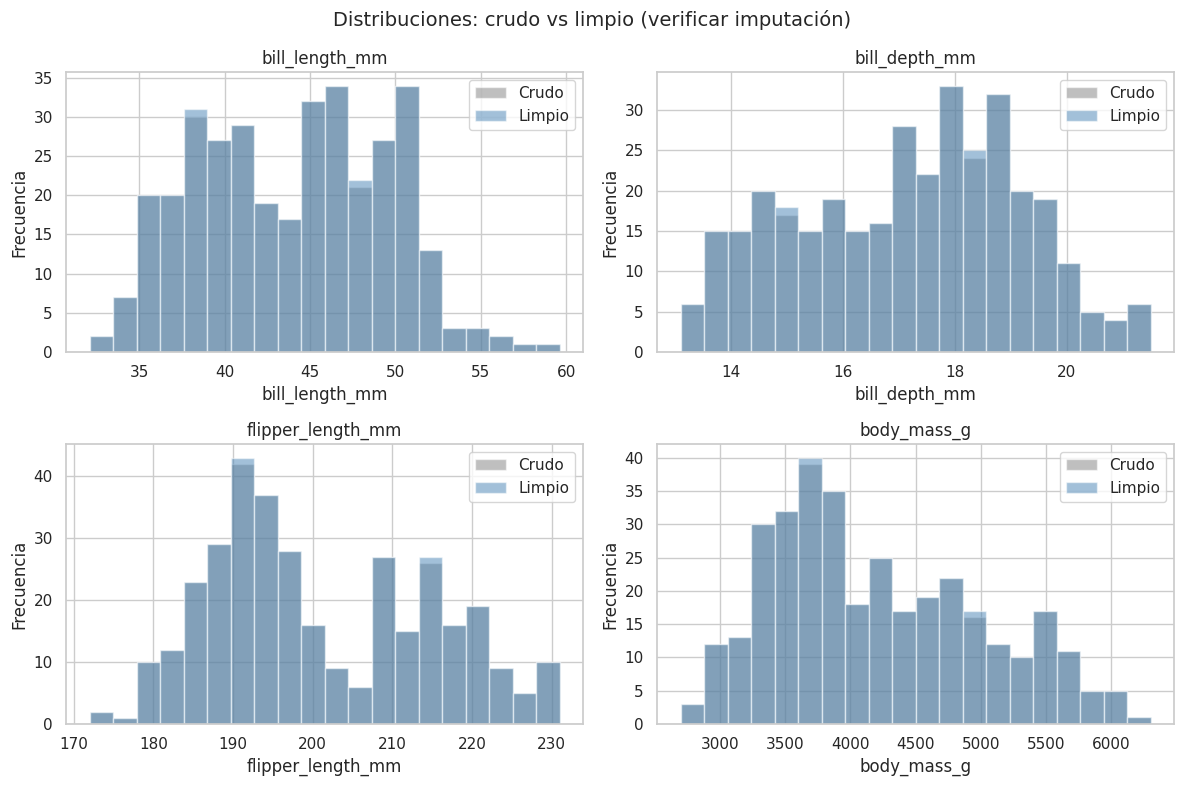

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var in zip(axes.flat, num_vars):
    ax.hist(df[var].dropna(), bins=20, alpha=0.5, label="Crudo", color="gray")
    ax.hist(df_clean[var], bins=20, alpha=0.5, label="Limpio", color="steelblue")
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Frecuencia")
    ax.legend()

fig.suptitle("Distribuciones: crudo vs limpio (verificar imputación)", fontsize=14)
plt.tight_layout()
plt.show()

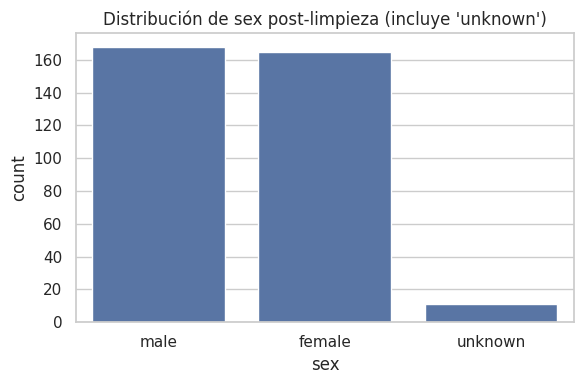

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="sex", order=df_clean["sex"].value_counts().index)
plt.title("Distribución de sex post-limpieza (incluye 'unknown')")
plt.tight_layout()
plt.show()

## Guardar CSV limpio


In [16]:
output_path = "notebooks/penguins_clean.csv"
df_clean.to_csv(output_path, index=False)
output_path


'notebooks/penguins_clean.csv'